In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, fftshift, fftfreq
from scipy.signal import windows

# Set style for better plots
plt.style.use('seaborn-v0_8-whitegrid')

# Common parameters
fs = 1000  # Sampling frequency (Hz)
T = 1.0    # Total duration (seconds)
N = int(fs * T)  # Number of samples
t = np.linspace(0, T, N, endpoint=False)  # Time vector



1(a) Generating sinusoidal signal (5 Hz)...
1(b) Plotting time-domain waveform...
1(c) Computing DTFT (continuous frequency spectrum)...
1(d) Computing DFT (discrete frequency spectrum)...


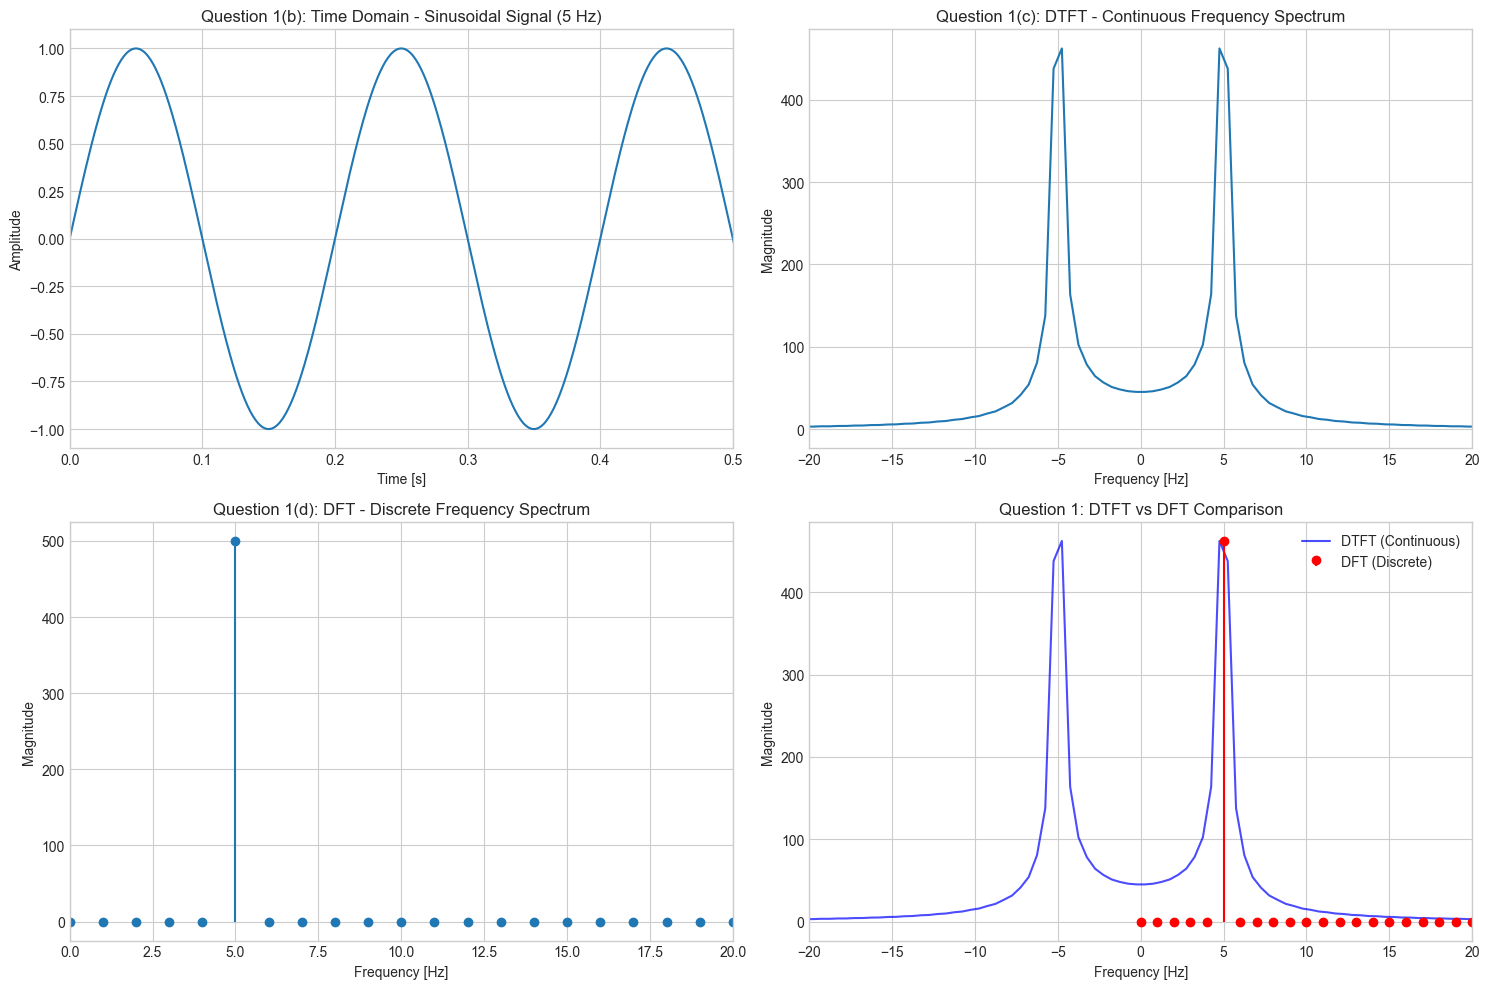

In [ ]:
# QUESTION 1: Basic Sinusoidal Signal

# Part 1(a): Generate basic sinusoidal signal
print("\n1(a) Generating sinusoidal signal (5 Hz)...")
f1 = 5  # Frequency (Hz)
signal1 = np.sin(2 * np.pi * f1 * t)

# Part 1(b): Plot time-domain waveform
print("1(b) Plotting time-domain waveform...")
plt.figure(figsize=(15, 10))

plt.subplot(2, 2, 1)
plt.plot(t, signal1)
plt.title('Question 1(b): Time Domain - Sinusoidal Signal (5 Hz)')
plt.xlabel('Time [s]')
plt.ylabel('Amplitude')
plt.grid(True)
plt.xlim(0, 0.5)  # Show first 0.5 seconds for clarity

# Part 1(c): Compute and plot DTFT (continuous frequency spectrum)
print("1(c) Computing DTFT (continuous frequency spectrum)...")
# For DTFT, we use a fine frequency resolution
freqs_dtft = np.linspace(-fs/2, fs/2, 2000)
dtft1 = np.zeros(len(freqs_dtft), dtype=complex)

for i, freq in enumerate(freqs_dtft):
    dtft1[i] = np.sum(signal1 * np.exp(-2j * np.pi * freq * t))

plt.subplot(2, 2, 2)
plt.plot(freqs_dtft, np.abs(dtft1))
plt.title('Question 1(c): DTFT - Continuous Frequency Spectrum')
plt.xlabel('Frequency [Hz]')
plt.ylabel('Magnitude')
plt.grid(True)
plt.xlim(-20, 20)

# Part 1(d): Compute and plot DFT (discrete frequency spectrum)
print("1(d) Computing DFT (discrete frequency spectrum)...")
dft1 = fft(signal1)
freqs_dft = fftfreq(N, 1/fs)

plt.subplot(2, 2, 3)
plt.stem(freqs_dft[:N//2], np.abs(dft1[:N//2]), basefmt=" ")
plt.title('Question 1(d): DFT - Discrete Frequency Spectrum')
plt.xlabel('Frequency [Hz]')
plt.ylabel('Magnitude')
plt.grid(True)
plt.xlim(0, 20)

# Combined plot for comparison
plt.subplot(2, 2, 4)
plt.plot(freqs_dtft, np.abs(dtft1), 'b-', label='DTFT (Continuous)', alpha=0.7)
plt.stem(freqs_dft[:N//2], np.abs(dft1[:N//2])/max(np.abs(dft1[:N//2]))*max(np.abs(dtft1)), 
         'r', basefmt=" ", label='DFT (Discrete)')
plt.title('Question 1: DTFT vs DFT Comparison')
plt.xlabel('Frequency [Hz]')
plt.ylabel('Magnitude')
plt.legend()
plt.grid(True)
plt.xlim(-20, 20)

plt.tight_layout()
plt.show()


2(a) Generating composite signal...
2(b) Plotting time-domain waveform...
2(c) Computing DTFT...
2(d) Computing DFT...


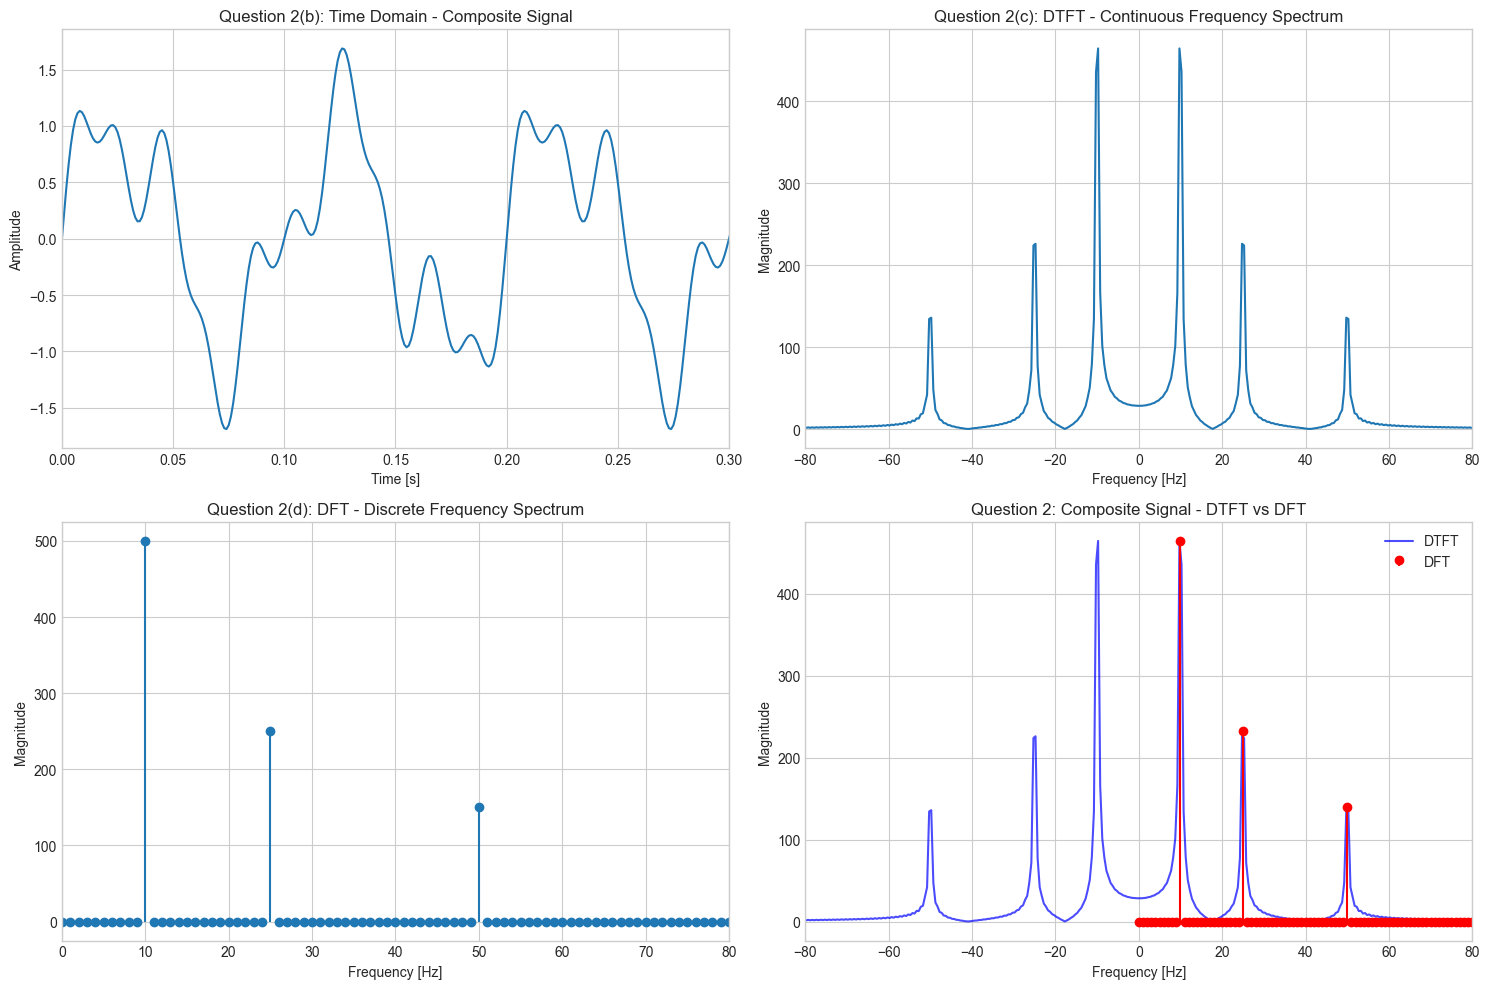

Expected frequency components: 10 Hz (A=1.0), 25 Hz (A=0.5), 50 Hz (A=0.3)


In [11]:
# QUESTION 2: Composite Signal

# Part 2(a): Generate composite signal
print("\n2(a) Generating composite signal...")
f2_1, A1 = 10, 1.0   # First component: 10 Hz, amplitude 1
f2_2, A2 = 25, 0.5   # Second component: 25 Hz, amplitude 0.5
f2_3, A3 = 50, 0.3   # Third component: 50 Hz, amplitude 0.3

signal2 = (A1 * np.sin(2 * np.pi * f2_1 * t) + 
           A2 * np.sin(2 * np.pi * f2_2 * t) + 
           A3 * np.sin(2 * np.pi * f2_3 * t))

# Part 2(b): Plot time-domain waveform
print("2(b) Plotting time-domain waveform...")
plt.figure(figsize=(15, 10))

plt.subplot(2, 2, 1)
plt.plot(t, signal2)
plt.title('Question 2(b): Time Domain - Composite Signal')
plt.xlabel('Time [s]')
plt.ylabel('Amplitude')
plt.grid(True)
plt.xlim(0, 0.3)

# Part 2(c): Compute and plot DTFT
print("2(c) Computing DTFT...")
dtft2 = np.zeros(len(freqs_dtft), dtype=complex)
for i, freq in enumerate(freqs_dtft):
    dtft2[i] = np.sum(signal2 * np.exp(-2j * np.pi * freq * t))

plt.subplot(2, 2, 2)
plt.plot(freqs_dtft, np.abs(dtft2))
plt.title('Question 2(c): DTFT - Continuous Frequency Spectrum')
plt.xlabel('Frequency [Hz]')
plt.ylabel('Magnitude')
plt.grid(True)
plt.xlim(-80, 80)

# Part 2(d): Compute and plot DFT
print("2(d) Computing DFT...")
dft2 = fft(signal2)

plt.subplot(2, 2, 3)
plt.stem(freqs_dft[:N//2], np.abs(dft2[:N//2]), basefmt=" ")
plt.title('Question 2(d): DFT - Discrete Frequency Spectrum')
plt.xlabel('Frequency [Hz]')
plt.ylabel('Magnitude')
plt.grid(True)
plt.xlim(0, 80)

# Analysis of frequency components
plt.subplot(2, 2, 4)
plt.plot(freqs_dtft, np.abs(dtft2), 'b-', label='DTFT', alpha=0.7)
plt.stem(freqs_dft[:N//2], np.abs(dft2[:N//2])/max(np.abs(dft2[:N//2]))*max(np.abs(dtft2)), 
         'r', basefmt=" ", label='DFT')
plt.title('Question 2: Composite Signal - DTFT vs DFT')
plt.xlabel('Frequency [Hz]')
plt.ylabel('Magnitude')
plt.legend()
plt.grid(True)
plt.xlim(-80, 80)

plt.tight_layout()
plt.show()

print(f"Expected frequency components: {f2_1} Hz (A={A1}), {f2_2} Hz (A={A2}), {f2_3} Hz (A={A3})")


3(a) Generating exponentially decaying signal...
3(b) Plotting time-domain waveform...
3(c) Computing DTFT...
3(d) Computing DFT...
3(e) Analyzing relationship between time and frequency domains...


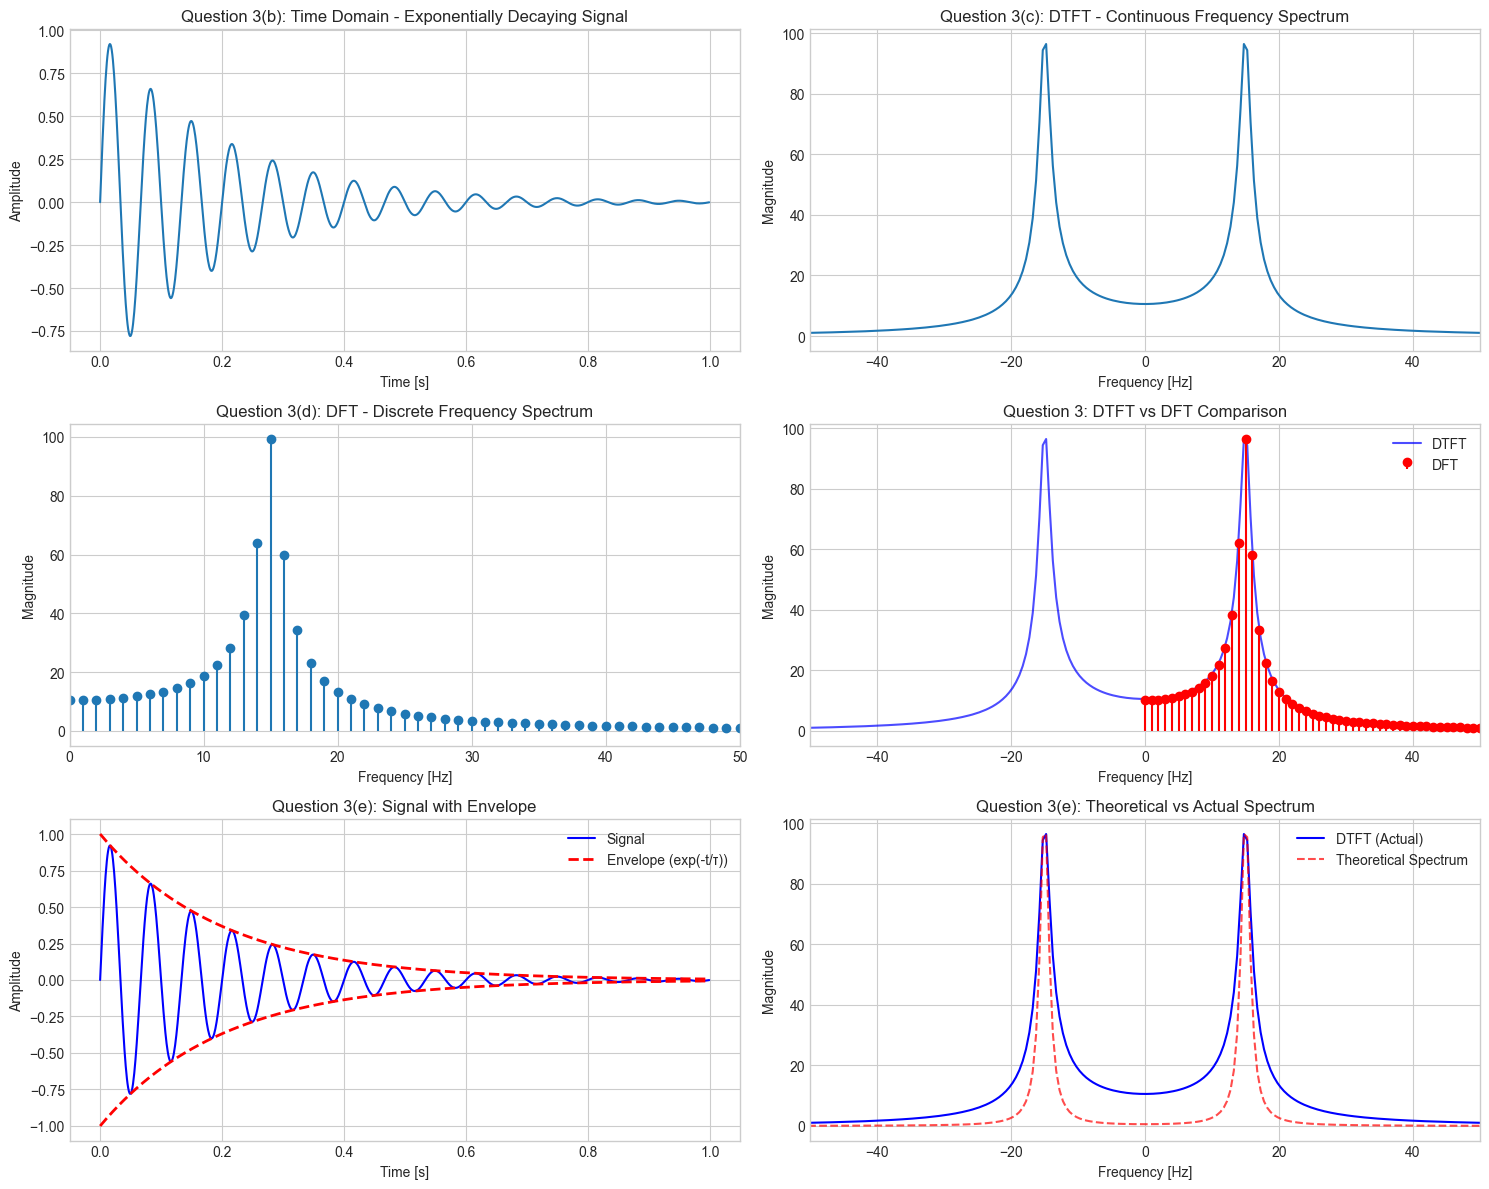


Analysis for Exponentially Decaying Signal:
- Carrier frequency: 15 Hz
- Decay time constant (τ): 0.2 seconds
- Bandwidth (approximate): 0.80 Hz
- The frequency spectrum shows broadening around the carrier frequency
- This demonstrates the time-frequency uncertainty principle


In [16]:
# QUESTION 3: Exponentially Decaying Signal

# Part 3(a): Generate exponentially decaying signal
print("\n3(a) Generating exponentially decaying signal...")
f3 = 15  # Frequency (Hz)
tau = 0.2  # Decay constant
signal3 = np.exp(-t/tau) * np.sin(2 * np.pi * f3 * t)

# Part 3(b): Plot time-domain waveform
print("3(b) Plotting time-domain waveform...")
plt.figure(figsize=(15, 12))

plt.subplot(3, 2, 1)
plt.plot(t, signal3)
plt.title('Question 3(b): Time Domain - Exponentially Decaying Signal')
plt.xlabel('Time [s]')
plt.ylabel('Amplitude')
plt.grid(True)

# Part 3(c): Compute and plot DTFT
print("3(c) Computing DTFT...")
dtft3 = np.zeros(len(freqs_dtft), dtype=complex)
for i, freq in enumerate(freqs_dtft):
    dtft3[i] = np.sum(signal3 * np.exp(-2j * np.pi * freq * t))

plt.subplot(3, 2, 2)
plt.plot(freqs_dtft, np.abs(dtft3))
plt.title('Question 3(c): DTFT - Continuous Frequency Spectrum')
plt.xlabel('Frequency [Hz]')
plt.ylabel('Magnitude')
plt.grid(True)
plt.xlim(-50, 50)

# Part 3(d): Compute and plot DFT
print("3(d) Computing DFT...")
dft3 = fft(signal3)

plt.subplot(3, 2, 3)
plt.stem(freqs_dft[:N//2], np.abs(dft3[:N//2]), basefmt=" ")
plt.title('Question 3(d): DFT - Discrete Frequency Spectrum')
plt.xlabel('Frequency [Hz]')
plt.ylabel('Magnitude')
plt.grid(True)
plt.xlim(0, 50)

# Part 3(e): Analysis
print("3(e) Analyzing relationship between time and frequency domains...")

# Comparison plot
plt.subplot(3, 2, 4)
plt.plot(freqs_dtft, np.abs(dtft3), 'b-', label='DTFT', alpha=0.7)
plt.stem(freqs_dft[:N//2], np.abs(dft3[:N//2])/max(np.abs(dft3[:N//2]))*max(np.abs(dtft3)), 
         'r', basefmt=" ", label='DFT')
plt.title('Question 3: DTFT vs DFT Comparison')
plt.xlabel('Frequency [Hz]')
plt.ylabel('Magnitude')
plt.legend()
plt.grid(True)
plt.xlim(-50, 50)

# Time-frequency analysis
plt.subplot(3, 2, 5)
# Envelope of the signal
envelope = np.exp(-t/tau)
plt.plot(t, signal3, 'b-', label='Signal')
plt.plot(t, envelope, 'r--', label='Envelope (exp(-t/τ))', linewidth=2)
plt.plot(t, -envelope, 'r--', linewidth=2)
plt.title('Question 3(e): Signal with Envelope')
plt.xlabel('Time [s]')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True)

# Theoretical analysis
plt.subplot(3, 2, 6)
# Theoretical Lorentzian spectrum for comparison
f_center = f3
gamma = 1/(2*np.pi*tau)  # Bandwidth parameter
theoretical_spec = 1/((freqs_dtft - f_center)**2 + gamma**2) + 1/((freqs_dtft + f_center)**2 + gamma**2)
theoretical_spec = theoretical_spec / max(theoretical_spec) * max(np.abs(dtft3))

plt.plot(freqs_dtft, np.abs(dtft3), 'b-', label='DTFT (Actual)')
plt.plot(freqs_dtft, theoretical_spec, 'r--', label='Theoretical Spectrum', alpha=0.7)
plt.title('Question 3(e): Theoretical vs Actual Spectrum')
plt.xlabel('Frequency [Hz]')
plt.ylabel('Magnitude')
plt.legend()
plt.grid(True)
plt.xlim(-50, 50)

plt.tight_layout()
plt.show()

print(f"\nAnalysis for Exponentially Decaying Signal:")
print(f"- Carrier frequency: {f3} Hz")
print(f"- Decay time constant (τ): {tau} seconds")
print(f"- Bandwidth (approximate): {1/(2*np.pi*tau):.2f} Hz")
print("- The frequency spectrum shows broadening around the carrier frequency")
print("- This demonstrates the time-frequency uncertainty principle")


4(a) Generating rectangular pulse signal...
4(b) Plotting time-domain waveform...
4(c) Computing DTFT...
4(d) Computing DFT...
4(e) Analyzing relationship between time and frequency domains...


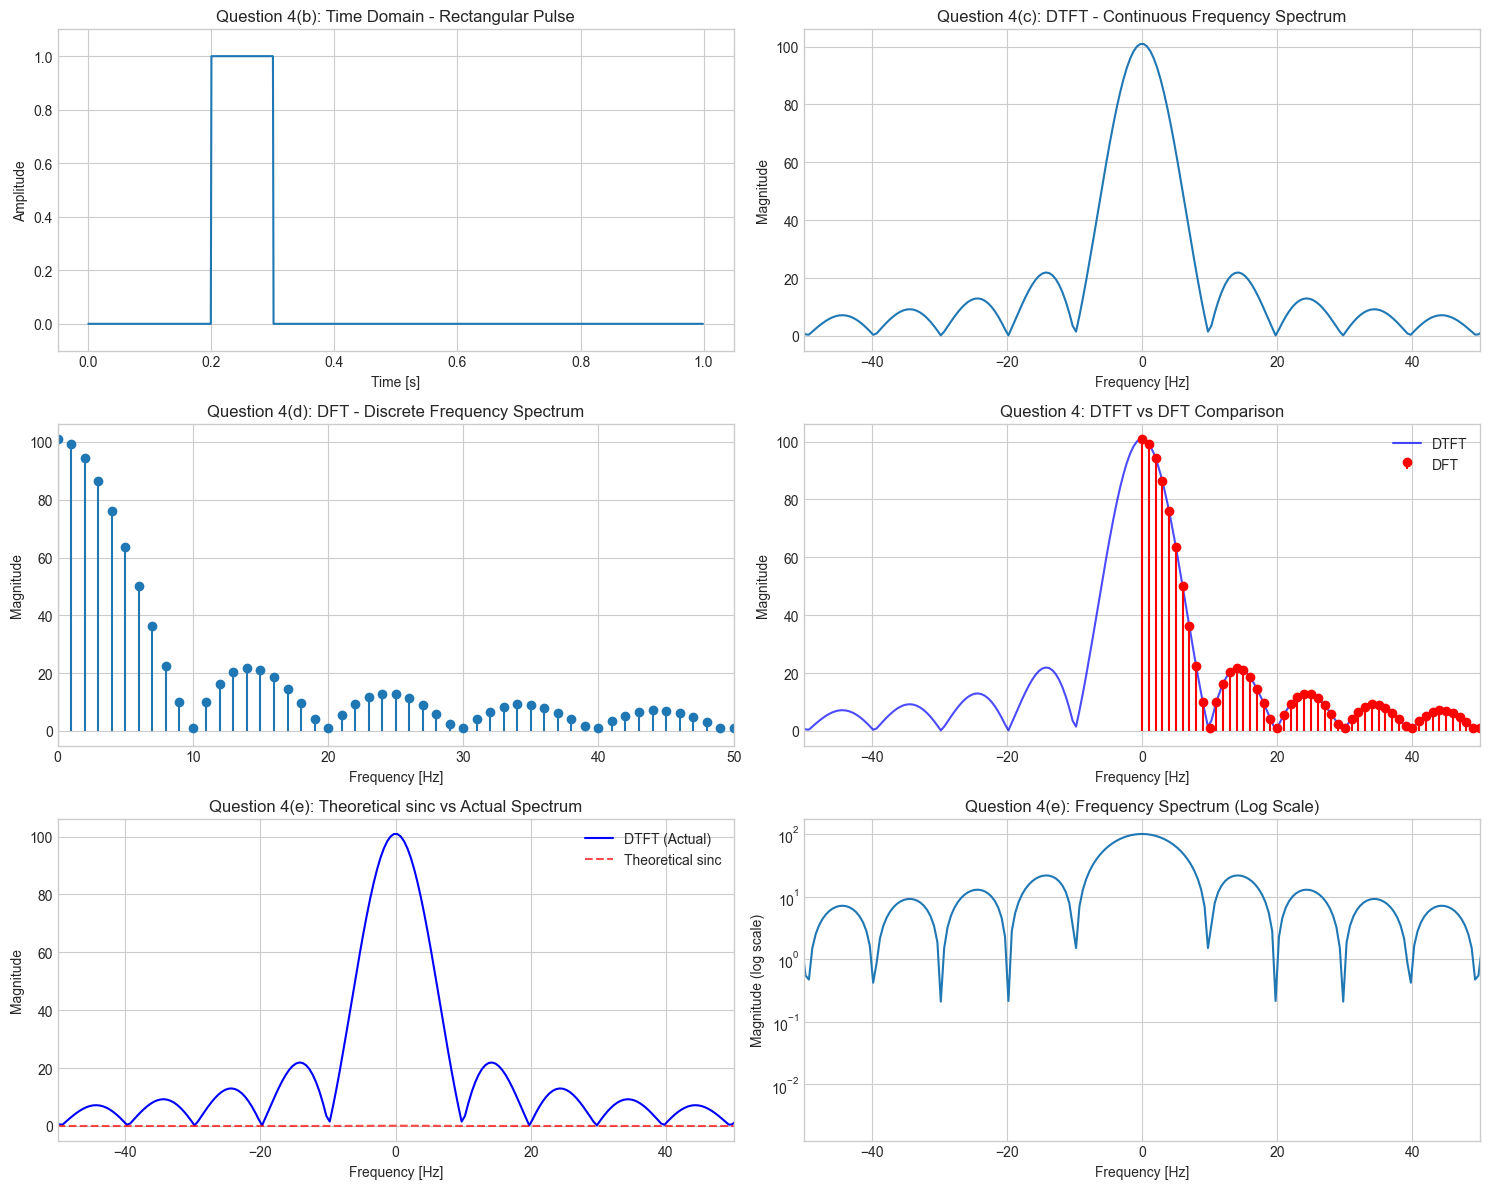


Analysis for Rectangular Pulse Signal:
- Pulse width: 0.1 seconds
- Main lobe width: 20.0 Hz
- First zero crossing: ±10.0 Hz
- Spectrum follows sinc function pattern
- Demonstrates inverse relationship: narrower pulse → wider spectrum


In [23]:
# QUESTION 4: Rectangular Pulse Signal

# Part 4(a): Generate rectangular pulse signal
print("\n4(a) Generating rectangular pulse signal...")
pulse_width = 0.1  # seconds
pulse_start = 0.2  # seconds
pulse_end = pulse_start + pulse_width

signal4 = np.zeros(N)
pulse_indices = np.where((t >= pulse_start) & (t <= pulse_end))[0]
signal4[pulse_indices] = 1.0

# Part 4(b): Plot time-domain waveform
print("4(b) Plotting time-domain waveform...")
plt.figure(figsize=(15, 12))

plt.subplot(3, 2, 1)
plt.plot(t, signal4)
plt.title('Question 4(b): Time Domain - Rectangular Pulse')
plt.xlabel('Time [s]')
plt.ylabel('Amplitude')
plt.grid(True)
plt.ylim(-0.1, 1.1)

# Part 4(c): Compute and plot DTFT
print("4(c) Computing DTFT...")
dtft4 = np.zeros(len(freqs_dtft), dtype=complex)
for i, freq in enumerate(freqs_dtft):
    dtft4[i] = np.sum(signal4 * np.exp(-2j * np.pi * freq * t))

plt.subplot(3, 2, 2)
plt.plot(freqs_dtft, np.abs(dtft4))
plt.title('Question 4(c): DTFT - Continuous Frequency Spectrum')
plt.xlabel('Frequency [Hz]')
plt.ylabel('Magnitude')
plt.grid(True)
plt.xlim(-50, 50)

# Part 4(d): Compute and plot DFT
print("4(d) Computing DFT...")
dft4 = fft(signal4)

plt.subplot(3, 2, 3)
plt.stem(freqs_dft[:N//2], np.abs(dft4[:N//2]), basefmt=" ")
plt.title('Question 4(d): DFT - Discrete Frequency Spectrum')
plt.xlabel('Frequency [Hz]')
plt.ylabel('Magnitude')
plt.grid(True)
plt.xlim(0, 50)

# Part 4(e): Analysis
print("4(e) Analyzing relationship between time and frequency domains...")

# Comparison plot
plt.subplot(3, 2, 4)
plt.plot(freqs_dtft, np.abs(dtft4), 'b-', label='DTFT', alpha=0.7)
plt.stem(freqs_dft[:N//2], np.abs(dft4[:N//2])/max(np.abs(dft4[:N//2]))*max(np.abs(dtft4)), 
         'r', basefmt=" ", label='DFT')
plt.title('Question 4: DTFT vs DFT Comparison')
plt.xlabel('Frequency [Hz]')
plt.ylabel('Magnitude')
plt.legend()
plt.grid(True)
plt.xlim(-50, 50)

# Theoretical sinc function comparison
plt.subplot(3, 2, 5)
# Theoretical sinc function for rectangular pulse
T_pulse = pulse_width
f_theoretical = np.linspace(-50, 50, 1000)
theoretical_spec_sinc = np.abs(T_pulse * np.sinc(f_theoretical * T_pulse))

plt.plot(freqs_dtft, np.abs(dtft4), 'b-', label='DTFT (Actual)')
plt.plot(f_theoretical, theoretical_spec_sinc, 'r--', label='Theoretical sinc', alpha=0.7)
plt.title('Question 4(e): Theoretical sinc vs Actual Spectrum')
plt.xlabel('Frequency [Hz]')
plt.ylabel('Magnitude')
plt.legend()
plt.grid(True)
plt.xlim(-50, 50)

# Log magnitude plot to see side lobes better
plt.subplot(3, 2, 6)
plt.semilogy(freqs_dtft, np.abs(dtft4) + 1e-10)  # Add small value to avoid log(0)
plt.title('Question 4(e): Frequency Spectrum (Log Scale)')
plt.xlabel('Frequency [Hz]')
plt.ylabel('Magnitude (log scale)')
plt.grid(True)
plt.xlim(-50, 50)

plt.tight_layout()
plt.show()

print(f"\nAnalysis for Rectangular Pulse Signal:")
print(f"- Pulse width: {pulse_width} seconds")
print(f"- Main lobe width: {2/pulse_width:.1f} Hz")
print(f"- First zero crossing: ±{1/pulse_width} Hz")
print("- Spectrum follows sinc function pattern")
print("- Demonstrates inverse relationship: narrower pulse → wider spectrum")

In [26]:
# SUMMARY AND COMPARISON

print("\n" + "="*70)
print("SUMMARY AND KEY OBSERVATIONS")
print("="*70)

print("\n1. SINUSOIDAL SIGNAL:")
print("   - Pure frequency component at exact frequency")
print("   - Dirac delta in ideal continuous case")
print("   - Finite width in practical implementation")

print("\n2. COMPOSITE SIGNAL:")
print("   - Multiple distinct frequency components")
print("   - Each component appears at its respective frequency")
print("   - Amplitudes proportional to time-domain amplitudes")

print("\n3. EXPONENTIALLY DECAYING SIGNAL:")
print("   - Broadened spectrum around carrier frequency")
print("   - Faster decay → wider bandwidth")
print("   - Demonstrates time-frequency trade-off")

print("\n4. RECTANGULAR PULSE:")
print("   - sinc-shaped frequency spectrum")
print("   - Narrower pulse → wider main lobe")
print("   - Side lobes decay slowly (Gibbs phenomenon)")

print("\n5. DTFT vs DFT COMPARISON:")
print("   - DTFT: Continuous frequency representation")
print("   - DFT: Discrete frequency sampling of DTFT")
print("   - DFT provides efficient computation via FFT algorithm")

print("\n" + "="*70)
print("ANALYSIS COMPLETE")
print("="*70)


SUMMARY AND KEY OBSERVATIONS

1. SINUSOIDAL SIGNAL:
   - Pure frequency component at exact frequency
   - Dirac delta in ideal continuous case
   - Finite width in practical implementation

2. COMPOSITE SIGNAL:
   - Multiple distinct frequency components
   - Each component appears at its respective frequency
   - Amplitudes proportional to time-domain amplitudes

3. EXPONENTIALLY DECAYING SIGNAL:
   - Broadened spectrum around carrier frequency
   - Faster decay → wider bandwidth
   - Demonstrates time-frequency trade-off

4. RECTANGULAR PULSE:
   - sinc-shaped frequency spectrum
   - Narrower pulse → wider main lobe
   - Side lobes decay slowly (Gibbs phenomenon)

5. DTFT vs DFT COMPARISON:
   - DTFT: Continuous frequency representation
   - DFT: Discrete frequency sampling of DTFT
   - DFT provides efficient computation via FFT algorithm

ANALYSIS COMPLETE


Vectorized DTFT time (M=4000, N=1000): 0.0539 s  [O(M·N)]
Zero-padded rFFT time (Npad=8000): 0.0003 s  [≈ O(N log N)]


/var/folders/03/k3m8qd4j6wv194nts7w8rldm0000gn/T/ipykernel_17154/69674043.py:26: RuntimeWarning: divide by zero encountered in matmul
  dtft_vec = exp_mat @ signal                                 # (M,)
/var/folders/03/k3m8qd4j6wv194nts7w8rldm0000gn/T/ipykernel_17154/69674043.py:26: RuntimeWarning: overflow encountered in matmul
  dtft_vec = exp_mat @ signal                                 # (M,)
/var/folders/03/k3m8qd4j6wv194nts7w8rldm0000gn/T/ipykernel_17154/69674043.py:26: RuntimeWarning: invalid value encountered in matmul
  dtft_vec = exp_mat @ signal                                 # (M,)


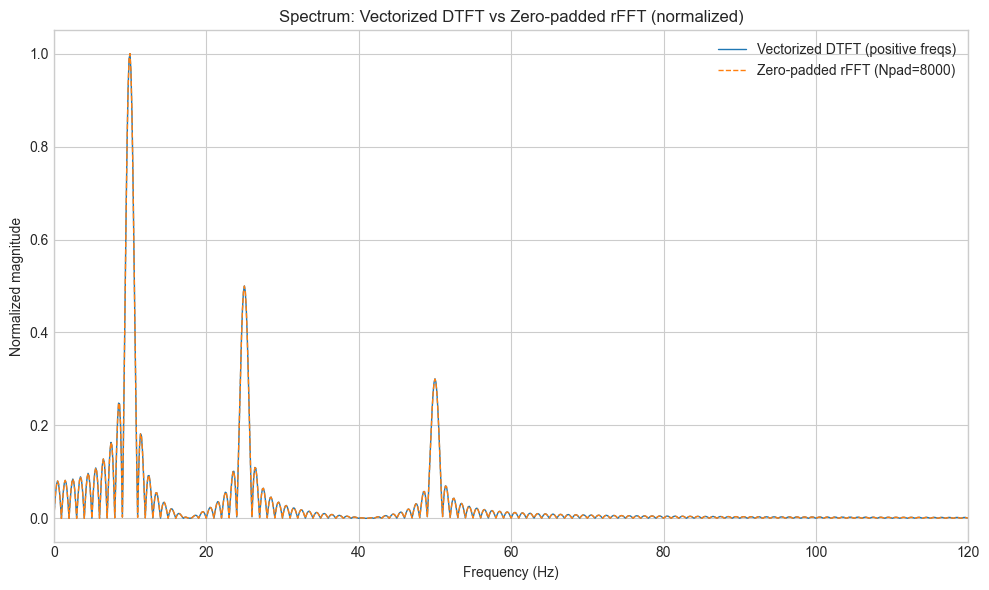

In [27]:
# snippet_1_dtft_vs_fft.py
import numpy as np
import matplotlib.pyplot as plt
import time

# ---------- Parameters ----------
fs = 1000           # sampling frequency (Hz)
T = 1.0             # duration (s)
N = int(fs * T)     # number of samples (keep moderate for DTFT test)
t = np.linspace(0, T, N, endpoint=False)

# Composite test signal (same as your composite signal)
f1, A1 = 10, 1.0
f2, A2 = 25, 0.5
f3, A3 = 50, 0.3
signal = A1*np.sin(2*np.pi*f1*t) + A2*np.sin(2*np.pi*f2*t) + A3*np.sin(2*np.pi*f3*t)

# Frequency sampling for DTFT (positive half only)
M = 4000                       # number of frequency bins for DTFT (positive frequencies)
freqs_dtft = np.linspace(0, fs/2, M)

# ---------- Vectorized DTFT (positive freqs only) ----------
t0 = time.time()
# build exponent matrix: shape (M, N) -> memory O(M*N). Use with caution for big M*N.
exp_mat = np.exp(-2j * np.pi * np.outer(freqs_dtft, t))  # (M, N)
dtft_vec = exp_mat @ signal                                 # (M,)
dtft_time = time.time() - t0

# ---------- Zero-padded rFFT (to get dense freq samples) ----------
Npad = 8 * N  # zero-padding factor (increases frequency sampling density)
t1 = time.time()
dft_zp = np.fft.rfft(signal, n=Npad)                 # positive freq bins
freqs_zp = np.fft.rfftfreq(Npad, d=1/fs)             # corresponding freqs
fft_time = time.time() - t1

# Interpolate FFT magnitude at DTFT freq points for direct comparison
mag_fft_interp = np.interp(freqs_dtft, freqs_zp, np.abs(dft_zp))

# ---------- Normalize for plotting clarity ----------
mag_dtft = np.abs(dtft_vec)
# Normalize both to same peak for visual comparison
mag_dtft_norm = mag_dtft / np.max(mag_dtft)
mag_fft_norm = mag_fft_interp / np.max(mag_fft_interp)

# ---------- Print timings ----------
print(f"Vectorized DTFT time (M={M}, N={N}): {dtft_time:.4f} s  [O(M·N)]")
print(f"Zero-padded rFFT time (Npad={Npad}): {fft_time:.4f} s  [≈ O(N log N)]")

# ---------- Plot ----------
plt.figure(figsize=(10, 6))
plt.plot(freqs_dtft, mag_dtft_norm, label='Vectorized DTFT (positive freqs)', linewidth=1)
plt.plot(freqs_dtft, mag_fft_norm, '--', label=f'Zero-padded rFFT (Npad={Npad})', linewidth=1)
plt.title('Spectrum: Vectorized DTFT vs Zero-padded rFFT (normalized)')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Normalized magnitude')
plt.xlim(0, 120)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()



Testing N = 256
rFFT time: 0.000027 s ; STFT time: 0.000245 s (nperseg=256, frames~1)

Testing N = 512
rFFT time: 0.000051 s ; STFT time: 0.000159 s (nperseg=256, frames~3)

Testing N = 1024
rFFT time: 0.000017 s ; STFT time: 0.000101 s (nperseg=256, frames~7)

Testing N = 2048
rFFT time: 0.000014 s ; STFT time: 0.000079 s (nperseg=256, frames~15)

Testing N = 4096
rFFT time: 0.000017 s ; STFT time: 0.000080 s (nperseg=256, frames~31)


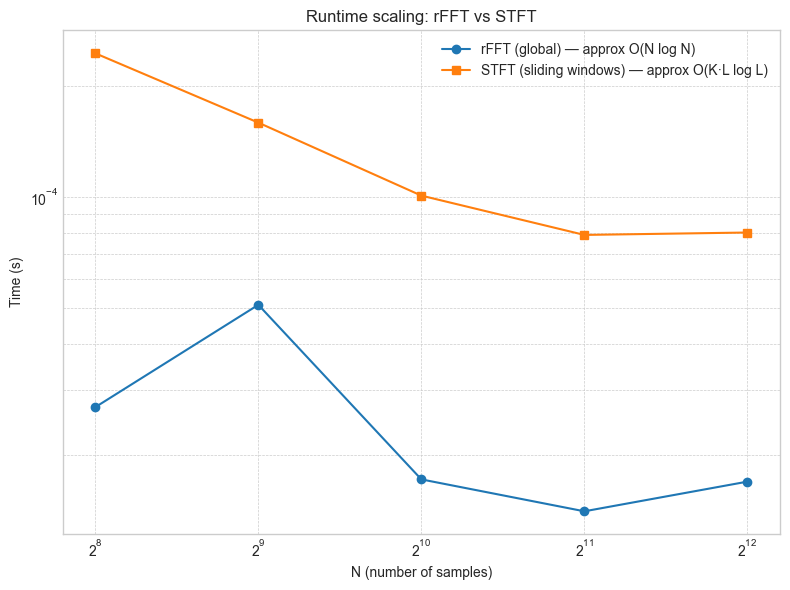


Summary (N, rFFT_time(s), STFT_time(s), nperseg used)
     256    0.000027    0.000245    nperseg=256
     512    0.000051    0.000159    nperseg=256
    1024    0.000017    0.000101    nperseg=256
    2048    0.000014    0.000079    nperseg=256
    4096    0.000017    0.000080    nperseg=256


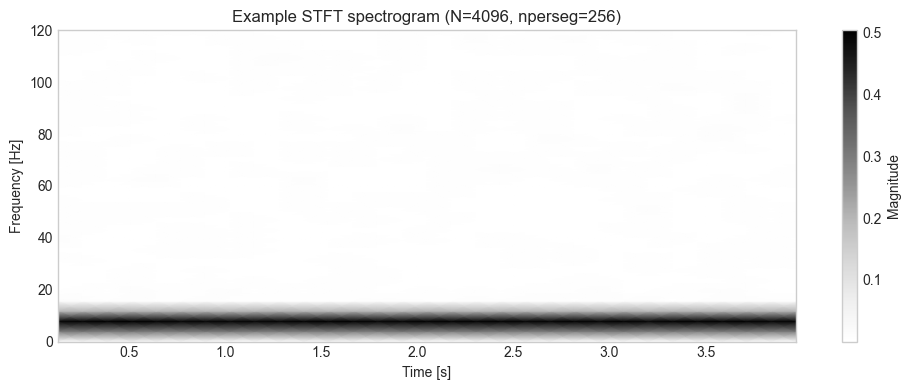

In [28]:
# benchmark_rfft_vs_stft.py
import numpy as np
import matplotlib.pyplot as plt
import time
from scipy.signal import stft

# ---------- Settings ----------
np.random.seed(0)
fs = 1000

# N values to test (moderate sizes to avoid memory/time issues)
N_list = [256, 512, 1024, 2048, 4096]

rfft_times = []
stft_times = []
Ns = []

# ---------- Benchmark loop ----------
for N in N_list:
    t = np.linspace(0, 1.0, N, endpoint=False)
    # test signal: tone + noise
    signal = np.sin(2 * np.pi * 30 * t) + 0.05 * np.random.randn(N)

    print(f"\nTesting N = {N}")

    # --- rFFT timing (global FFT of whole signal) ---
    try:
        t0 = time.time()
        _ = np.fft.rfft(signal)
        r_time = time.time() - t0
    except Exception as e:
        print(f"rFFT error for N={N}: {e}")
        r_time = np.nan

    # --- STFT timing ---
    # choose nperseg (window length) sensibly: smaller than or equal to N
    nperseg = min(256, N)
    noverlap = nperseg // 2

    try:
        t1 = time.time()
        f_stft, t_stft, Zxx = stft(signal, fs=fs, nperseg=nperseg, noverlap=noverlap, boundary=None)
        stf_time = time.time() - t1
    except Exception as e:
        print(f"STFT error for N={N}: {e}")
        stf_time = np.nan

    print(f"rFFT time: {r_time:.6f} s ; STFT time: {stf_time:.6f} s (nperseg={nperseg}, frames~{len(t_stft)})")

    Ns.append(N)
    rfft_times.append(r_time)
    stft_times.append(stf_time)

# Convert to arrays
Ns = np.array(Ns)
rfft_times = np.array(rfft_times)
stft_times = np.array(stft_times)

# ---------- Plot runtime scaling (log-log) ----------
plt.figure(figsize=(8,6))
plt.loglog(Ns, rfft_times, 'o-', label='rFFT (global) — approx O(N log N)')
plt.loglog(Ns, stft_times, 's-', label='STFT (sliding windows) — approx O(K·L log L)')
plt.xscale("log", base=2)
plt.yscale("log", base=10)
plt.xlabel('N (number of samples)')
plt.ylabel('Time (s)')
plt.title('Runtime scaling: rFFT vs STFT')
plt.grid(True, which="both", ls="--", linewidth=0.5)
plt.legend()
plt.tight_layout()
plt.show()

# ---------- Print summary table ----------
print("\nSummary (N, rFFT_time(s), STFT_time(s), nperseg used)")
for N, rt, st in zip(Ns, rfft_times, stft_times):
    nperseg = min(256, N)
    print(f"  {N:6d}   {np.nan_to_num(rt):9.6f}   {np.nan_to_num(st):9.6f}    nperseg={nperseg}")

# ---------- Example spectrogram for largest N ----------
N_example = Ns[-1]
t_ex = np.linspace(0, 1.0, N_example, endpoint=False)
signal_ex = np.sin(2 * np.pi * 30 * t_ex) + 0.05 * np.random.randn(N_example)
nperseg_ex = min(256, N_example)
noverlap_ex = nperseg_ex // 2

f_ex, tt_ex, Zxx_ex = stft(signal_ex, fs=fs, nperseg=nperseg_ex, noverlap=noverlap_ex, boundary=None)
plt.figure(figsize=(10,4))
plt.pcolormesh(tt_ex, f_ex, np.abs(Zxx_ex), shading='gouraud')
plt.title(f'Example STFT spectrogram (N={N_example}, nperseg={nperseg_ex})')
plt.ylabel('Frequency [Hz]')
plt.xlabel('Time [s]')
plt.ylim(0, 120)
plt.colorbar(label='Magnitude')
plt.tight_layout()
plt.show()
